<a href="https://colab.research.google.com/github/lip6666/-/blob/main/%E7%AC%AC%E4%B8%80%E7%89%88%E8%83%BD%E8%B7%91%E9%80%9A%E7%9A%84%E4%BB%A3%E7%A0%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python -m pip install -U pip
!pip install ultralytics pandas "pillow<12" "scikit-image<0.26" opencv-python pyyaml matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ultralytics]


In [ ]:
import os
import sys
import torch
import cv2
import ultralytics
import pandas
import PIL
import skimage

print("Python:", sys.version)
print("ultralytics:", ultralytics.__version__)
print("torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("cv2:", cv2.__version__)
print("pandas:", pandas.__version__)
print("pillow:", PIL.__version__)
print("scikit-image:", skimage.__version__)

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
else:
    print("running on CPU")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
ultralytics: 8.4.31
torch: 2.10.0+cu128
CUDA: 12.8
cuda available: True
cv2: 4.13.0
pandas: 2.2.2
pillow: 11.3.0
scikit-image: 0.25.2
gpu name: Tesla T4


In [ ]:
import os
import cv2
import json
import yaml
import shutil
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from skimage.measure import label, regionprops
from ultralytics import YOLO
import torch

warnings.filterwarnings("ignore")

# =========================
# 0. Runtime settings
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 2
IMGSZ = 640
EPOCHS = 50
BATCH = 8 if torch.cuda.is_available() else 2

print("DEVICE:", DEVICE)
print("NUM_WORKERS:", NUM_WORKERS)
print("BATCH:", BATCH)

# =========================
# 1. Paths and classes
# =========================
ROOT = Path('/content/drive/MyDrive/IDB_matrix_wear')
OUTPUT_DIR = Path('/content/drive/MyDrive/wear_project/output_yolo_seg_wear')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_TRAIN_DIR = ROOT / 'train'
RAW_VAL_DIR = ROOT / 'val'
RAW_TEST_DIR = ROOT / 'test'

YOLO_ROOT = ROOT / 'yolo_seg_dataset'
YOLO_TRAIN_IMG = YOLO_ROOT / 'images' / 'train'
YOLO_VAL_IMG = YOLO_ROOT / 'images' / 'val'
YOLO_TEST_IMG = YOLO_ROOT / 'images' / 'test'

YOLO_TRAIN_LBL = YOLO_ROOT / 'labels' / 'train'
YOLO_VAL_LBL = YOLO_ROOT / 'labels' / 'val'
YOLO_TEST_LBL = YOLO_ROOT / 'labels' / 'test'

DATA_YAML = YOLO_ROOT / 'data.yaml'

ROI_DIR = ROOT / 'roi_masks'  # optional

CLASS_NAMES = [
    'abrasive wear',
    'fatigue wear',
    'wear debris',
]
CLASS_TO_ID = {n: i for i, n in enumerate(CLASS_NAMES)}

CLASS_COLORS = {
    'abrasive wear': (255, 80, 80),
    'fatigue wear': (80, 255, 120),
    'wear debris': (255, 220, 80),
    'roi': (255, 255, 255),
    'unknown_region': (255, 140, 0),
}

LABEL_ALIASES = {
    'abrasive wear': 'abrasive wear',
    'abrasive_wear': 'abrasive wear',
    'abrasive': 'abrasive wear',
    'abrasive_groove': 'abrasive wear',
    'groove': 'abrasive wear',

    'fatigue wear': 'fatigue wear',
    'fatigue_wear': 'fatigue wear',
    'fatigue': 'fatigue wear',
    'spall_delam': 'fatigue wear',
    'spall': 'fatigue wear',
    'delam': 'fatigue wear',
    'delamination': 'fatigue wear',
    'crack': 'fatigue wear',

    'wear debris': 'wear debris',
    'wear_debris': 'wear debris',
    'debris': 'wear debris',
    'transfer_film': 'wear debris',
    'defect_pore': 'wear debris',
    'pore': 'wear debris',
}

IMAGE_EXTS = ['.tiff', '.tif', '.png', '.jpg', '.jpeg', '.bmp', '.webp']

print('ROOT:', ROOT)
print('RAW_TRAIN_DIR:', RAW_TRAIN_DIR)
print('RAW_VAL_DIR:', RAW_VAL_DIR)
print('RAW_TEST_DIR:', RAW_TEST_DIR)
print('YOLO_ROOT:', YOLO_ROOT)
print('CLASS_NAMES:', CLASS_NAMES)

assert ROOT.exists(), f"ROOT 不存在: {ROOT}"
assert RAW_TRAIN_DIR.exists(), f"训练目录不存在: {RAW_TRAIN_DIR}"
assert RAW_VAL_DIR.exists(), f"验证目录不存在: {RAW_VAL_DIR}"

# =========================
# 2. Helpers
# =========================
def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def resolve_image_dir(split_dir: Path) -> Path:
    p1 = split_dir / 'images'
    return p1 if p1.exists() else split_dir

def list_images_in_dir(img_dir: Path):
    files = []
    for ext in IMAGE_EXTS:
        files.extend(img_dir.glob(f'*{ext}'))
        files.extend(img_dir.glob(f'*{ext.upper()}'))
    return sorted(list(set(files)))

def build_image_index(img_dir: Path):
    idx = {}
    for p in list_images_in_dir(img_dir):
        idx[p.name] = p
        idx[p.name.lower()] = p
        idx[p.stem] = p
        idx[p.stem.lower()] = p
    return idx

def normalize_label_name(label):
    if label is None:
        return None
    s = str(label).strip()
    if s in LABEL_ALIASES:
        return LABEL_ALIASES[s]
    s2 = s.lower().strip().replace('-', ' ').replace('_', ' ')
    s2 = ' '.join(s2.split())
    return LABEL_ALIASES.get(s2, None)

def normalize_points(points):
    out = []
    for p in points:
        if isinstance(p, dict):
            x, y = p.get('x', None), p.get('y', None)
        else:
            if len(p) < 2:
                continue
            x, y = p[0], p[1]
        if x is None or y is None:
            continue
        out.append([float(x), float(y)])
    return out

def polygon_area(points):
    area = 0.0
    n = len(points)
    for i in range(n):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % n]
        area += x1 * y2 - x2 * y1
    return abs(area) / 2.0

def load_image_size(img_path, fallback_h=None, fallback_w=None):
    try:
        with Image.open(img_path) as im:
            w, h = im.size
        return h, w
    except Exception:
        if fallback_h is not None and fallback_w is not None:
            return int(fallback_h), int(fallback_w)
        raise

def resolve_image_for_json(jf: Path, img_dir: Path, image_index: dict, data: dict):
    image_path_in_json = data.get('imagePath', '')
    candidates = []

    if image_path_in_json:
        raw_name = Path(str(image_path_in_json)).name
        candidates.extend([raw_name, raw_name.lower(), Path(raw_name).stem, Path(raw_name).stem.lower()])

    stem = jf.stem
    candidates.extend([stem, stem.lower()])
    for ext in IMAGE_EXTS:
        candidates.extend([
            f'{stem}{ext}', f'{stem}{ext.upper()}',
            f'{stem.lower()}{ext}', f'{stem.lower()}{ext.upper()}'
        ])

    for key in candidates:
        if key in image_index:
            return image_index[key]
    return None

def save_image_as_3ch(src_path: Path, dst_path: Path):
    img = cv2.imread(str(src_path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f'无法读取图片: {src_path}')

    # 灰度图 (H, W)
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    # 单通道 (H, W, 1)
    elif len(img.shape) == 3 and img.shape[2] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    # 4通道 (H, W, 4)
    elif len(img.shape) == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    # 3通道则保持不变

    ok = cv2.imwrite(str(dst_path), img)
    if not ok:
        raise ValueError(f'保存图片失败: {dst_path}')

def reset_yolo_dataset_dir():
    if YOLO_ROOT.exists():
        print(f'删除旧数据集目录: {YOLO_ROOT}')
        shutil.rmtree(YOLO_ROOT)
    YOLO_ROOT.mkdir(parents=True, exist_ok=True)

# =========================
# 3. Labelme -> YOLO Seg
# =========================
def points_to_yolo_seg(points, w, h):
    arr = []
    for x, y in points:
        xn = min(max(x / w, 0.0), 1.0)
        yn = min(max(y / h, 0.0), 1.0)
        arr.extend([xn, yn])
    return arr

def convert_labelme_split_to_yolo(src_dir: Path, dst_img_dir: Path, dst_lbl_dir: Path):
    ensure_dir(dst_img_dir)
    ensure_dir(dst_lbl_dir)

    img_dir = resolve_image_dir(src_dir)
    image_index = build_image_index(img_dir)
    json_files = sorted(src_dir.glob('*.json'))

    print(f'[{src_dir.name}] JSON 数量: {len(json_files)}')
    print(f'[{src_dir.name}] 图片目录: {img_dir}')

    used_images = 0
    used_anns = 0
    skipped_no_image = 0
    skipped_unknown_label = 0
    skipped_bad_shape = 0
    empty_label_files = 0

    for jf in json_files:
        try:
            with open(jf, 'r', encoding='utf-8') as f:
                data = json.load(f)
        except Exception as e:
            print(f'跳过损坏 JSON: {jf.name}, err={e}')
            continue

        img_path = resolve_image_for_json(jf, img_dir, image_index, data)
        if img_path is None or (not img_path.exists()):
            skipped_no_image += 1
            print(f'跳过 {jf.name}: 找不到对应图片')
            continue

        h = data.get('imageHeight')
        w = data.get('imageWidth')
        try:
            h, w = load_image_size(img_path, h, w)
        except Exception as e:
            print(f'跳过 {jf.name}: 读取尺寸失败 {e}')
            continue

        base_name = jf.stem
        dst_img = dst_img_dir / f'{base_name}.png'
        save_image_as_3ch(img_path, dst_img)

        lines = []
        for shape in data.get('shapes', []):
            shape_type = shape.get('shape_type', 'polygon')
            if shape_type != 'polygon':
                skipped_bad_shape += 1
                continue

            label_name = normalize_label_name(shape.get('label', ''))
            if label_name not in CLASS_NAMES:
                skipped_unknown_label += 1
                continue

            points = normalize_points(shape.get('points', []))
            if len(points) < 3:
                skipped_bad_shape += 1
                continue

            area = polygon_area(points)
            if area <= 1e-6:
                skipped_bad_shape += 1
                continue

            seg = points_to_yolo_seg(points, w, h)
            if len(seg) < 6:
                skipped_bad_shape += 1
                continue

            cls_id = CLASS_TO_ID[label_name]
            line = ' '.join([str(cls_id)] + [f'{v:.6f}' for v in seg])
            lines.append(line)
            used_anns += 1

        txt_path = dst_lbl_dir / f'{base_name}.txt'
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines))

        if len(lines) == 0:
            empty_label_files += 1
            print(f'警告: {jf.name} 没有有效标注，生成空标签文件')

        used_images += 1

    print(f'[{src_dir.name}] 转换完成')
    print('used_images:', used_images)
    print('used_anns:', used_anns)
    print('skipped_no_image:', skipped_no_image)
    print('skipped_unknown_label:', skipped_unknown_label)
    print('skipped_bad_shape:', skipped_bad_shape)
    print('empty_label_files:', empty_label_files)

    if used_images == 0:
        raise RuntimeError(f'{src_dir} 没有成功转换出任何图片')

def write_data_yaml():
    data = {
        'path': str(YOLO_ROOT),
        'train': 'images/train',
        'val': 'images/val',
        'names': CLASS_NAMES,
    }

    test_img_dir = YOLO_ROOT / 'images' / 'test'
    if test_img_dir.exists() and len(list(test_img_dir.glob('*'))) > 0:
        data['test'] = 'images/test'

    with open(DATA_YAML, 'w', encoding='utf-8') as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)
    print('Saved:', DATA_YAML)

def summarize_dataset():
    for split in ['train', 'val', 'test']:
        img_dir = YOLO_ROOT / 'images' / split
        lbl_dir = YOLO_ROOT / 'labels' / split
        if not img_dir.exists():
            continue

        imgs = [p for p in img_dir.glob('*') if p.is_file()]
        lbls = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
        empty_lbls = 0
        for lp in lbls:
            try:
                txt = lp.read_text(encoding='utf-8').strip()
                if txt == '':
                    empty_lbls += 1
            except Exception:
                pass

        print(f'[{split}] images={len(imgs)}, labels={len(lbls)}, empty_labels={empty_lbls}')

def prepare_datasets():
    reset_yolo_dataset_dir()

    convert_labelme_split_to_yolo(RAW_TRAIN_DIR, YOLO_TRAIN_IMG, YOLO_TRAIN_LBL)
    convert_labelme_split_to_yolo(RAW_VAL_DIR, YOLO_VAL_IMG, YOLO_VAL_LBL)

    if RAW_TEST_DIR.exists():
        test_jsons = list(RAW_TEST_DIR.glob('*.json'))
        if len(test_jsons) > 0:
            convert_labelme_split_to_yolo(RAW_TEST_DIR, YOLO_TEST_IMG, YOLO_TEST_LBL)
        else:
            print('[test] 目录存在，但没有 JSON，跳过 test 转换')
    else:
        print('[test] 不存在，跳过 test 转换')

    write_data_yaml()
    summarize_dataset()

prepare_datasets()

# =========================
# 4. Load model
# =========================
def load_seg_model():
    candidates = [
        'yolov8n-seg.pt',
        'yolo11n-seg.pt',
    ]
    last_err = None
    for ckpt in candidates:
        try:
            print(f'Trying model: {ckpt}')
            return YOLO(ckpt), ckpt
        except Exception as e:
            print(f'Failed: {ckpt} -> {e}')
            last_err = e
    raise RuntimeError(f'无法加载分割预训练权重: {last_err}')

model, model_name = load_seg_model()
print("Using model:", model_name)

# =========================
# 5. Train
# =========================
train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=NUM_WORKERS,
    project=str(OUTPUT_DIR),
    name='wear_seg',
    pretrained=True,
    patience=20,
    verbose=True,
    seed=SEED,
    deterministic=True,
)

print(train_results)

# =========================
# 6. Find best model
# =========================
def find_best_pt(project_dir: Path, run_name='wear_seg'):
    p = project_dir / run_name / 'weights' / 'best.pt'
    if p.exists():
        return p

    cands = sorted(project_dir.glob(f'{run_name}*/weights/best.pt'))
    if len(cands) > 0:
        return cands[-1]

    raise FileNotFoundError(f'找不到 best.pt, looked in: {project_dir}')

best_pt = find_best_pt(OUTPUT_DIR, 'wear_seg')
print('best model:', best_pt)

best_model = YOLO(str(best_pt))

# =========================
# 7. Val
# =========================
val_metrics = best_model.val(
    data=str(DATA_YAML),
    split='val',
    imgsz=IMGSZ,
    device=DEVICE,
    workers=NUM_WORKERS,
)

print(val_metrics)
try:
    print("val seg mAP50-95:", val_metrics.seg.map)
    print("val seg mAP50:", val_metrics.seg.map50)
    print("val seg mAP75:", val_metrics.seg.map75)
except Exception:
    pass

# =========================
# 8. Test (optional)
# =========================
try:
    with open(DATA_YAML, 'r', encoding='utf-8') as f:
        data_cfg = yaml.safe_load(f)

    if 'test' in data_cfg and data_cfg['test']:
        test_metrics = best_model.val(
            data=str(DATA_YAML),
            split='test',
            imgsz=IMGSZ,
            device=DEVICE,
            workers=NUM_WORKERS,
        )
        print(test_metrics)
        try:
            print("test seg mAP50-95:", test_metrics.seg.map)
            print("test seg mAP50:", test_metrics.seg.map50)
            print("test seg mAP75:", test_metrics.seg.map75)
        except Exception:
            pass
    else:
        print("未配置 test 集，跳过 test 评估")
except Exception as e:
    print("test 评估跳过:", e)

DEVICE: 0
NUM_WORKERS: 2
BATCH: 8
ROOT: /content/drive/MyDrive/IDB_matrix_wear
RAW_TRAIN_DIR: /content/drive/MyDrive/IDB_matrix_wear/train
RAW_VAL_DIR: /content/drive/MyDrive/IDB_matrix_wear/val
RAW_TEST_DIR: /content/drive/MyDrive/IDB_matrix_wear/test
YOLO_ROOT: /content/drive/MyDrive/IDB_matrix_wear/yolo_seg_dataset
CLASS_NAMES: ['abrasive wear', 'fatigue wear', 'wear debris']
删除旧数据集目录: /content/drive/MyDrive/IDB_matrix_wear/yolo_seg_dataset
[train] JSON 数量: 80
[train] 图片目录: /content/drive/MyDrive/IDB_matrix_wear/train
[train] 转换完成
used_images: 80
used_anns: 1760
skipped_no_image: 0
skipped_unknown_label: 0
skipped_bad_shape: 0
empty_label_files: 0
[val] JSON 数量: 20
[val] 图片目录: /content/drive/MyDrive/IDB_matrix_wear/val
[val] 转换完成
used_images: 20
used_anns: 478
skipped_no_image: 0
skipped_unknown_label: 0
skipped_bad_shape: 0
empty_label_files: 0
[test] 目录存在，但没有 JSON，跳过 test 转换
Saved: /content/drive/MyDrive/IDB_matrix_wear/yolo_seg_dataset/data.yaml
[train] images=80, labels=80, empt

Using best model: /content/drive/MyDrive/wear_project/output_yolo_seg_wear/wear_seg2/weights/best.pt
验证集图片数: 20
抽样图片:
 - WC-663Cu400047.png
 - WC-663Cu350041.png
 - WC-663Cu400048.png
 - WC-663Cu350047.png
 - WC-663Cu400044.png
 - WC-663Cu350044.png
Processing [1/6]: WC-663Cu400047.png


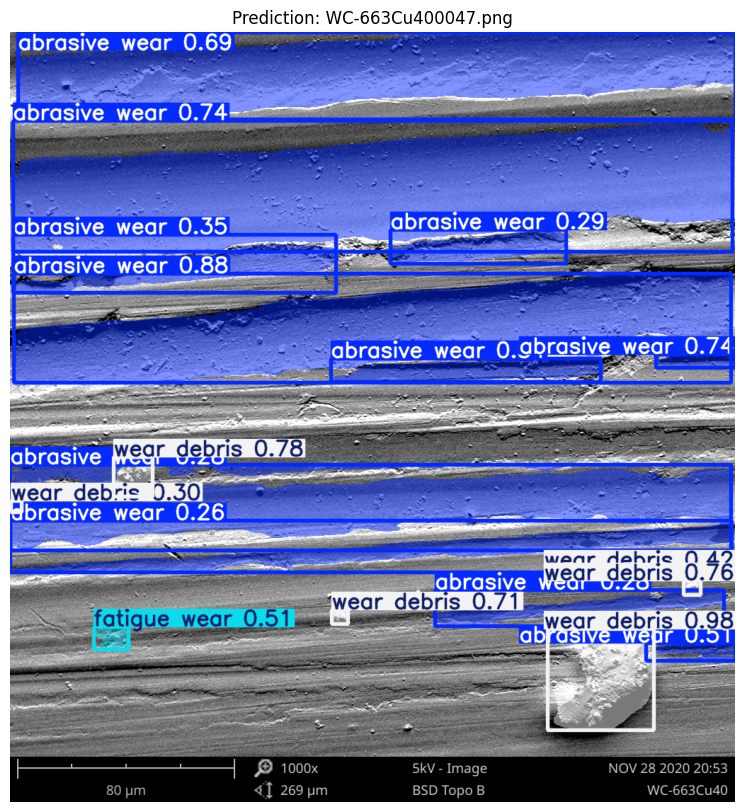

已保存: /content/drive/MyDrive/wear_project/output_yolo_seg_wear/visualizations_val/pred_WC-663Cu400047.png
Processing [2/6]: WC-663Cu350041.png


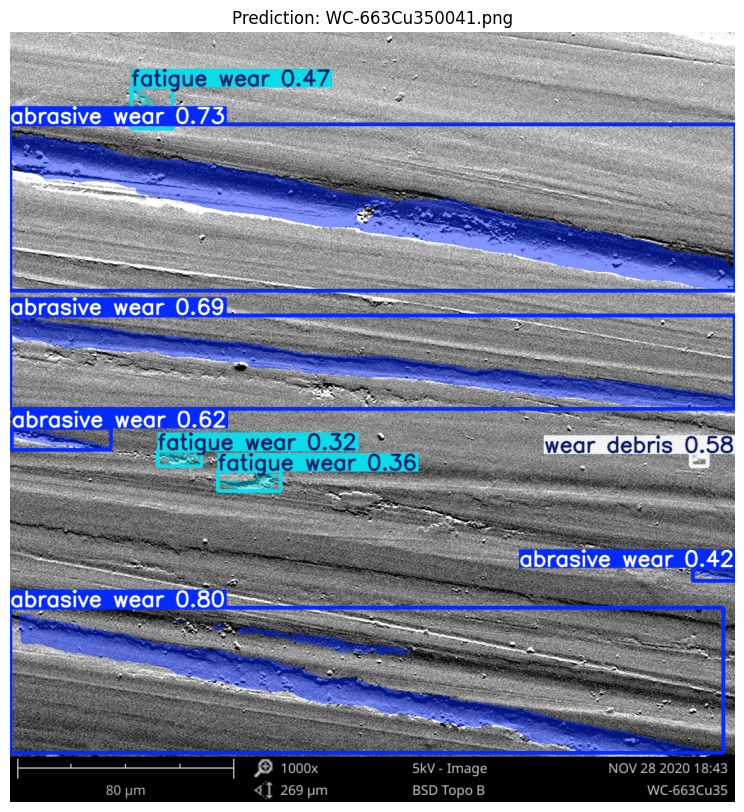

已保存: /content/drive/MyDrive/wear_project/output_yolo_seg_wear/visualizations_val/pred_WC-663Cu350041.png
Processing [3/6]: WC-663Cu400048.png


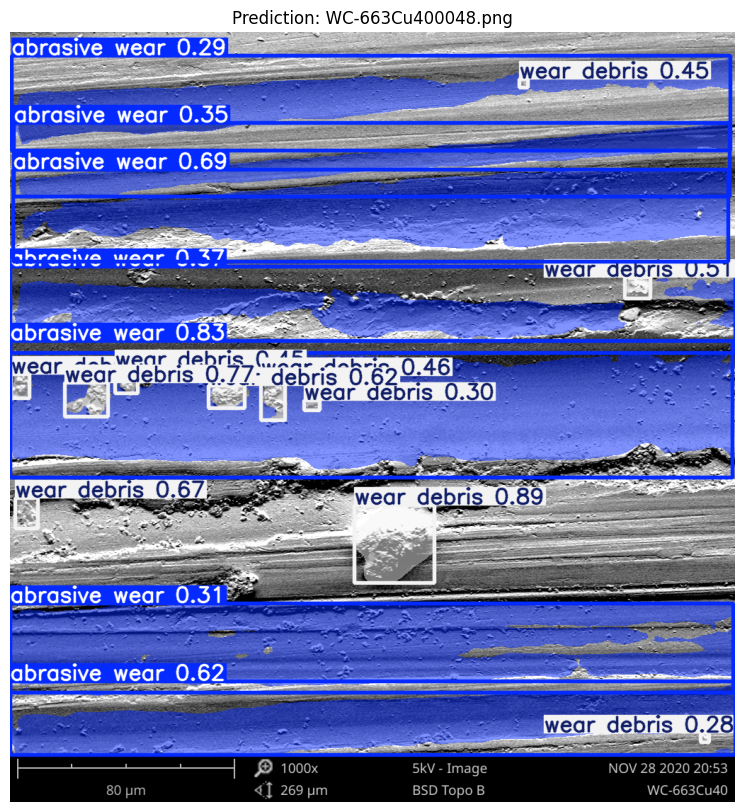

已保存: /content/drive/MyDrive/wear_project/output_yolo_seg_wear/visualizations_val/pred_WC-663Cu400048.png
Processing [4/6]: WC-663Cu350047.png


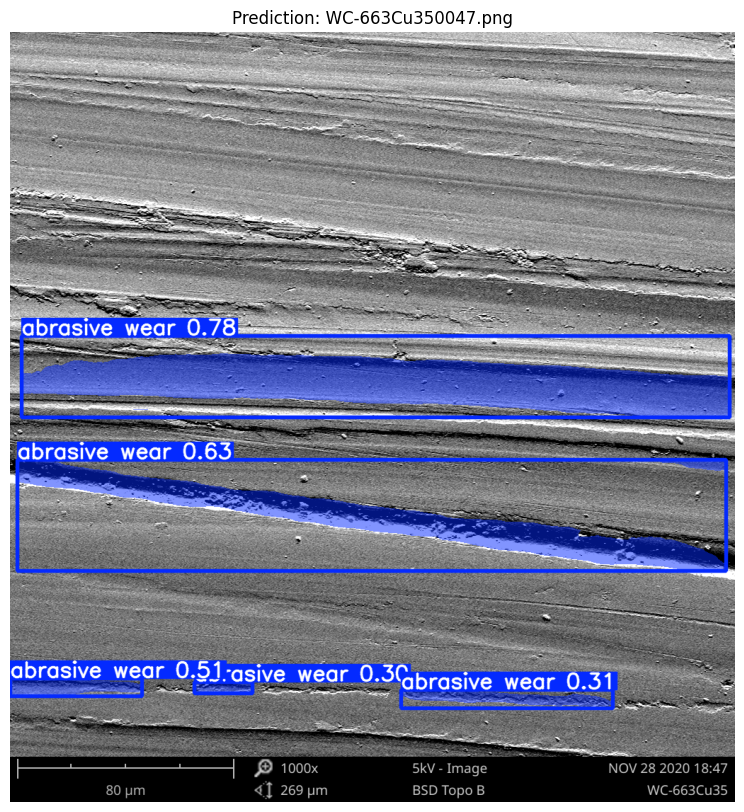

已保存: /content/drive/MyDrive/wear_project/output_yolo_seg_wear/visualizations_val/pred_WC-663Cu350047.png
Processing [5/6]: WC-663Cu400044.png


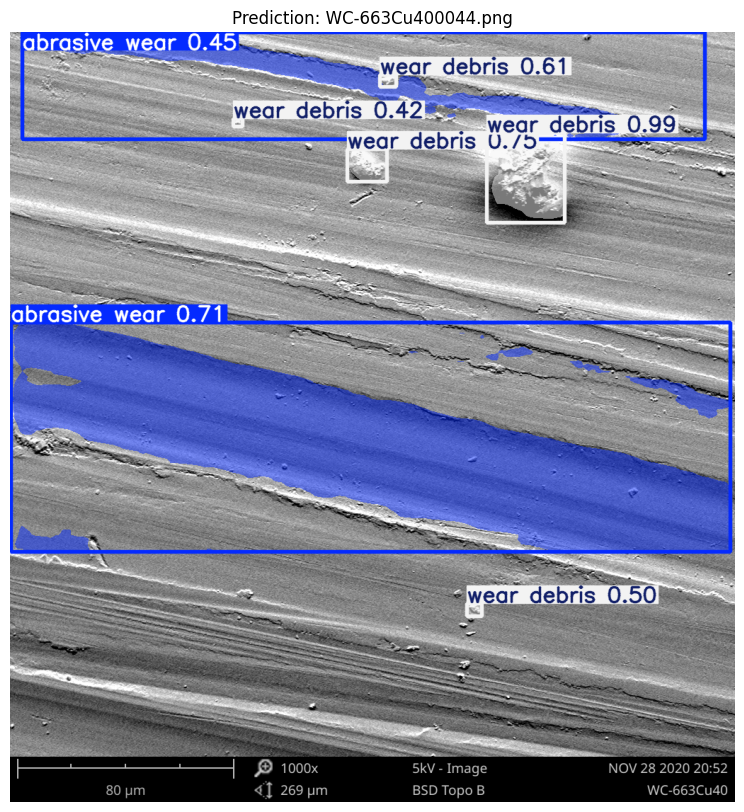

已保存: /content/drive/MyDrive/wear_project/output_yolo_seg_wear/visualizations_val/pred_WC-663Cu400044.png
Processing [6/6]: WC-663Cu350044.png


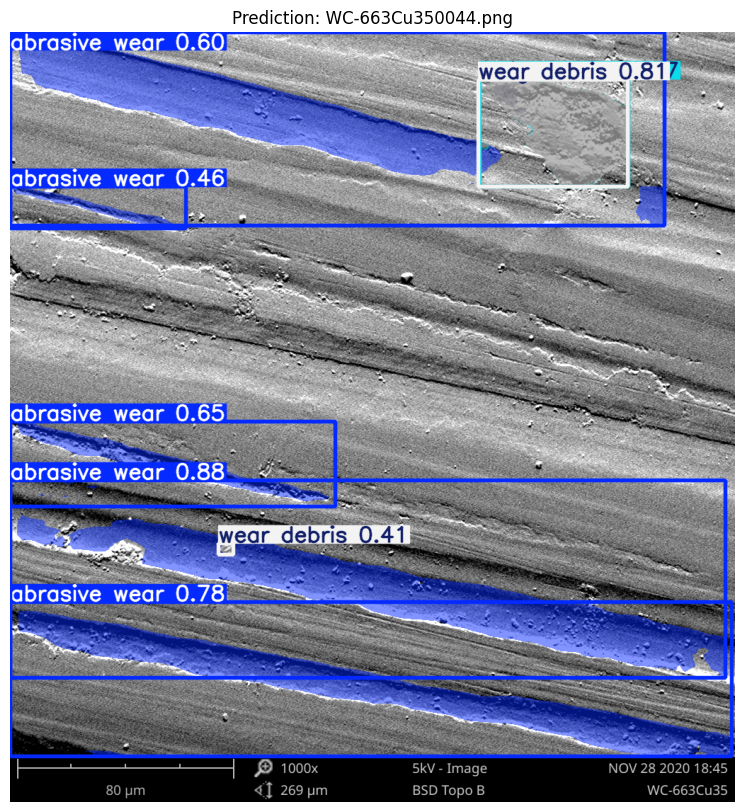

已保存: /content/drive/MyDrive/wear_project/output_yolo_seg_wear/visualizations_val/pred_WC-663Cu350044.png
全部可视化结果已保存到: /content/drive/MyDrive/wear_project/output_yolo_seg_wear/visualizations_val


In [ ]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from PIL import Image

# =========================
# 0. Paths
# =========================
ROOT = Path('/content/drive/MyDrive/IDB_matrix_wear')
OUTPUT_DIR = Path('/content/drive/MyDrive/wear_project/output_yolo_seg_wear')
VAL_IMG_DIR = ROOT / 'yolo_seg_dataset' / 'images' / 'val'

VIS_DIR = OUTPUT_DIR / 'visualizations_val'
VIS_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 1. Find best.pt
# =========================
def find_best_pt(project_dir: Path, run_prefix='wear_seg'):
    candidates = sorted(project_dir.glob(f'{run_prefix}*/weights/best.pt'))
    if len(candidates) == 0:
        raise FileNotFoundError(f'找不到 best.pt in {project_dir}')
    return candidates[-1]

best_pt = find_best_pt(OUTPUT_DIR, 'wear_seg')
print("Using best model:", best_pt)

model = YOLO(str(best_pt))

# =========================
# 2. Collect val images
# =========================
IMAGE_EXTS = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff', '*.webp']
val_images = []
for ext in IMAGE_EXTS:
    val_images.extend(list(VAL_IMG_DIR.glob(ext)))

val_images = sorted(val_images)
print(f'验证集图片数: {len(val_images)}')

assert len(val_images) > 0, f'验证集目录没有图片: {VAL_IMG_DIR}'

# =========================
# 3. Random sample images
# =========================
NUM_SAMPLES = min(6, len(val_images))   # 可改
sample_images = random.sample(val_images, NUM_SAMPLES)

print("抽样图片:")
for p in sample_images:
    print(" -", p.name)

# =========================
# 4. Predict and visualize
# =========================
for i, img_path in enumerate(sample_images, 1):
    print(f'Processing [{i}/{NUM_SAMPLES}]: {img_path.name}')

    results = model.predict(
        source=str(img_path),
        imgsz=640,
        conf=0.25,
        iou=0.5,
        device=0,
        save=False,
        retina_masks=True,
        verbose=False
    )

    r = results[0]

    # Ultralytics 自带绘图结果（带 mask / box / label）
    plotted = r.plot()

    # BGR -> RGB for matplotlib
    plotted_rgb = plotted[:, :, ::-1]

    # 显示
    plt.figure(figsize=(10, 10))
    plt.imshow(plotted_rgb)
    plt.title(f'Prediction: {img_path.name}')
    plt.axis('off')
    plt.show()

    # 保存
    save_path = VIS_DIR / f'pred_{img_path.stem}.png'
    Image.fromarray(plotted_rgb).save(save_path)
    print(f'已保存: {save_path}')

print(f'全部可视化结果已保存到: {VIS_DIR}')